In [1]:
%help

The following SysML v2 magic commands are available.
For help on a specific command, use "%help <COMMAND>" or "%<cmd> -h".

%eval		Evaluate a given expression.
%export		Save a file of the JSON representation of the abstract syntax tree rooted in the named element.
%help		Get a list of available commands or help on a specific command
%list		List loaded library packages or the results of a given query
%show		Print the abstract syntax tree rooted in a named element
%publish	Publish to the repository the modele elements rooted in a named element
%view		Render the view specified by the named view usage
%viz		Visualize the name model elements


In [2]:
%show -h

Usage: %show [--style=<STYLE>] <NAME>

Print the abstract syntax tree rooted in <NAME>. <NAME> must be fully qualified.

<STYLE> is also case insensitive. The possible style names are:
   TREE		Hierarchically indented representation with only identifying information
   JSON		Complete JSON representation of the tree


In [5]:
attribute test_result = test_a + test_b;

AttributeUsage test_a (bf44af62-1d3a-4368-96bf-fa86ed264f43)
AttributeUsage test_b (4e28823f-8383-4c65-a3b2-336139c88cfb)
AttributeUsage test_result (feaecc49-69dd-4e79-a016-7275b6207e63)


In [7]:
%eval test_result

LiteralInteger 10 (b33c2fdd-f5eb-4925-a033-6f3350920579)


In [15]:
part test_part{
    attribute test_a := 5;
    attribute test_b := 6;
}

requirement def test_requirement{
    subject test_part;
    require constraint{
        test_a > test_b
    }
}


PartUsage test_part (b6be3280-a85e-4fd2-be9b-f8274bb4ac85)
RequirementDefinition test_requirement (fbff1782-d6a1-4e00-922c-eb9ff5b96e5c)


In [18]:
satisfy requirement test_A : test_requirement;

SatisfyRequirementUsage test_A (d05bc362-7466-4b34-b646-1c3998ff0abf)


In [22]:
package 'Turbojet Stage Analysis' {
	private import Quantities::ScalarQuantityValue;
	private import MeasurementReferences::DimensionOneValue;
	private import ISQ::*;
	
	package 'Thermodynamic Functions' {
	    calc def 'Ideal Gas Law' { in rho; in R_bar; in T;
	    	return p = rho * R_bar * T;
	    }
	    
	    calc def 'Reversible Adiabatic Compression Density' { in rho_1; in p_1; in p_2; in gamma;
	    	return rho_2 = rho_1 * (p_2 / p_1)^(1/gamma);
	    }
	    
	    calc def 'Reversible Adiabatic Compression Temperature' { in T_1; in p_1; in p_2; in gamma;
	    	return T_2 = T_1 * (p_2 / p_1)**((gamma - 1) / gamma);
	    }
	    
	    calc def 'Total Pressure' { in P_static; in rho; in V;
	    	1/2 * rho * V^2 + P_static
	    }
	    
	    // Showing explicit parameter typing
	    calc def 'Total Temperature' { in T_static : TemperatureValue; in Cp : DimensionOneValue; in V : VolumeValue;
	    	return : TemperatureValue = 1/(2 * Cp) * V^2 + T_static;
	    }
	    
	    calc def 'Total Enthalpy' { in h_total; in h_static; in V;
	    	return H_total = 1/2 * V^2 + h_static;
	    }
	}
	
	package 'Thermodynamics Structure' {
	    part def 'Ideal Gas Parcel' {
	        comment
	            /*
	            The parcel is an infinitesimal volume used to analyze points in a flow
	            */
	        attribute 'Molar Mass';
	        attribute 'Density';
	        attribute 'Pressure';
	        attribute 'Temperature';
	        attribute 'Enthalpy';
	        attribute 'Specific Gas Constant';
	    }
	    
	    part def 'Moving Ideal Gas Parcel' specializes 'Ideal Gas Parcel' {
	        comment about 'Stagnation Pressure'
	            /*
	            Stagnation pressure is the pressure of the parcel if the kinetic energy defined by its
	            velocity in a given coordinate frame is converted to gas internal energy through deceleration
	            to a velocity that matches the current frame.
	            */
	        attribute 'Stagnation Pressure';
	        attribute 'Stagnation Temperature';
	        attribute 'Stagnation Enthalpy';
	        
	        comment about 'Static Pressure'
	            /*
	            Static pressure is the pressure of the parcel as it moves
	            */
	        attribute 'Static Pressure' redefines 'Ideal Gas Parcel'::'Pressure';
	        attribute 'Static Temperature' redefines 'Ideal Gas Parcel'::'Temperature';
	        attribute 'Static Enthalpy' redefines 'Ideal Gas Parcel'::'Enthalpy';
	    }
	    
	    action def 'Thermodynamic Process'; // need start and end shots to show beginning and end attributes
	    
	    action def 'Adiabatic Process' specializes 'Thermodynamic Process' {
	        /*
	        Thermodynamic process typically have their states defined at beginning and end
	        of the process (since these starts are path-independent)
	        */
	        action 'Stage 1' :>> start;
	        action 'Stage 2' :>> done;
	    }
	    
	    action def 'Reversible Adiabatic Process' specializes 'Adiabatic Process';
	}
	
	package 'Low-Pressure Compressor Analysis' {
	    
	    part 'Analysis Context' {
	        private import 'Thermodynamic Functions'::*;
	        
	        part 'Inlet Gas' : 'Thermodynamics Structure'::'Moving Ideal Gas Parcel' {
	        	// Explicit binding notation
	        	calc 'Solve for Pressure1' : 'Ideal Gas Law';
	        	bind 'Density' = 'Solve for Pressure1'.rho;
	        	bind 'Specific Gas Constant' = 'Solve for Pressure1'.R_bar;
	        	bind 'Static Temperature' = 'Solve for Pressure1'.T;
	        	bind 'Static Pressure' = 'Solve for Pressure1'.p;	        	
	        	
	        	// Shorthand parameter binding notation
	            calc 'Solve for Pressure2' : 'Ideal Gas Law' {
	                in rho = 'Density';
	                in R_bar = 'Specific Gas Constant';
	                in T = 'Static Temperature';
				}				
				            
	            // Invocation expression notation
	            attribute :>> 'Static Pressure' = 'Ideal Gas Law'('Density', 'Specific Gas Constant', 'Static Temperature');

	            // Equation as a constraint (note "==")
	            constraint { 'Static Pressure' == 'Ideal Gas Law'('Density', 'Specific Gas Constant', 'Static Temperature') }
	        }
	    }
	}	
	
}

Package Turbojet Stage Analysis (116ea915-8b78-42e2-96f6-6d19d11423b4)


In [27]:
%show 'Turbojet Stage Analysis'::'Low-Pressure Compressor Analysis'::'Analysis Context'

MagicArgsParseException: Too many positional arguments.

In [28]:
package CalculationExample {
	private import ISQ::*;
	private import NumericalFunctions::*;
	
	part def VehiclePart {
		attribute m : MassValue;
	}
	
	part def Vehicle :> VehiclePart;
	
	part vehicle : Vehicle {		
		part eng : VehiclePart;		
		part trans : VehiclePart;
		attribute ::> m = ms.totalMass;
	}
	
	calc def MassSum {
		in partMasses : MassValue[0..*];
		return totalMass : MassValue = sum(partMasses);
	}
	
	calc ms: MassSum {
		in partMasses = (vehicle.eng.m, vehicle.trans.m);
		return totalMass;
	}
	
	part vehicles[*] = (vehicle, vehicle);
	attribute masses1[*] = (vehicles as VehiclePart).m;
	attribute masses2[*] = (vehicles as vehicle).m;
}

Package CalculationExample (4c75f126-0534-40b2-8019-ae5fc66ab4cb)


In [32]:
%viz ActionTest

ERROR:Couldn't resolve reference to Element 'ActionTest'


In [36]:
package StateTest {
	attribute def Sig {
		x;
	}
	attribute def Exit;
	
	part p;
	
	action act;
	
	state def S {
		do action A;
		entry; then S1;
		
		state S1;
			accept s : Sig
			do action D
			then S2;
				
		state S2 {
			do send new Sig(T.s.x) to p;
			state S3;
		}
		accept Exit then done;
		
		transition
			first S1
			accept s : Sig
			do action D
			then S2.S3;
		
		transition T
			first S2.S3
			accept s : Sig via p
			if true
			do send s to p
			then S1;
			
		exit act;
		
		state S3 {
			state S3a;
		}
		
		transition first S3.S3a then S1; 
	}
	
	state s0 {
  		state s1 {
    		state s2;
  		}
  		state s3 {
  			state s4;
  		}
  		transition t1 first s1.s2 then s3.s4;
	}
	
	state s parallel {
		state s1;
		state s2;
	}
	
	state s4 {
		do action a;
  		action c;
	}
	
	state s5 :> s4 {
  		do action b :>> c;
	}
	
}

ERROR:no viable alternative at input 'state' (31.sysml line : 20 column : 3)
ERROR:no viable alternative at input 'do' (31.sysml line : 21 column : 4)
ERROR:missing '}' at 'new' (31.sysml line : 21 column : 12)
ERROR:no viable alternative at input 'Sig' (31.sysml line : 21 column : 16)
ERROR:no viable alternative at input '(' (31.sysml line : 21 column : 19)
ERROR:no viable alternative at input '.' (31.sysml line : 21 column : 21)
ERROR:no viable alternative at input '.' (31.sysml line : 21 column : 23)
ERROR:no viable alternative at input ')' (31.sysml line : 21 column : 25)
ERROR:missing EOF at 'accept' (31.sysml line : 24 column : 3)


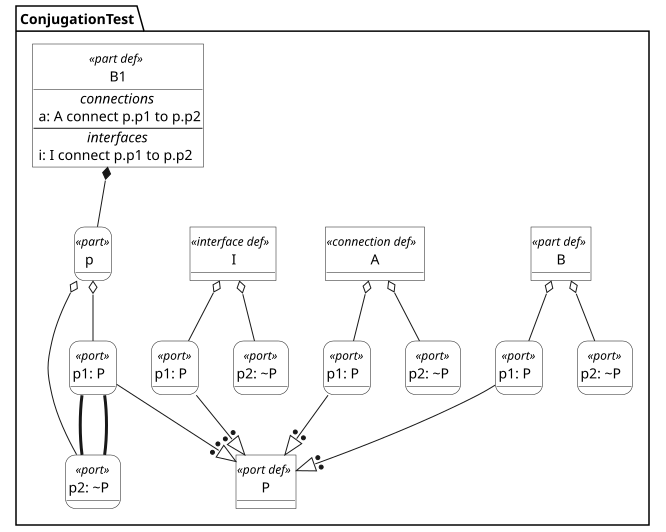

In [35]:
%viz ConjugationTest

In [4]:
attribute no1 = 1.0;
attribute no2= 1;
attribute no3= no1+no2;

AttributeUsage no1 (d0f16b70-9da4-4471-8d02-f35c00a03b02)
AttributeUsage no2 (d386b3d2-d820-4e90-b88b-5b61f2356b29)
AttributeUsage no3 (1409beb4-89f3-4549-bc0a-ad8623965e7a)


In [6]:
%eval no3

LiteralRational 2.0 (50cbdabc-1a11-42b4-b0c0-ad540815a194)


AttributeUsage no3 (1409beb4-89f3-4549-bc0a-ad8623965e7a)
